# CNN Experiment 3 — Local Directory Dataset and MobileNetV2 Transfer Learning

This notebook downloads the small TensorFlow flower dataset, extracts it into class folders, loads it with `image_dataset_from_directory`, and trains a MobileNetV2 classifier. The image archive is cached by Keras and is not committed to the repository.

## 1. Imports and Reproducibility

In [1]:
import os
import random
import warnings

os.environ.setdefault("KERAS_HOME", os.path.abspath(".keras"))
os.environ.setdefault("MPLCONFIGDIR", os.path.abspath(".mplconfig"))

import numpy as np
import tensorflow as tf

SEED = 42
FAST_RUN = os.getenv("ASSIGNMENT_FAST_RUN", "0") == "1"
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)
try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

warnings.filterwarnings("ignore")
print("TensorFlow version:", tf.__version__)
print("Available GPU devices:", tf.config.list_physical_devices("GPU"))
print("Fast validation mode:", FAST_RUN)

from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras import Model, Sequential
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import BatchNormalization, Dense, Dropout, GlobalAveragePooling2D, Input, RandomFlip, RandomRotation, RandomZoom
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input

sns.set_theme(style="whitegrid")

TensorFlow version: 2.20.0
Available GPU devices: []
Fast validation mode: True


## 2. Download and Inspect the Local Directory Dataset

After extraction, the data has the required directory form:

```text
flower_photos/
    daisy/
    dandelion/
    roses/
    sunflowers/
    tulips/
```

In [2]:
DATASET_URL = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
archive_path = tf.keras.utils.get_file("flower_photos.tgz", origin=DATASET_URL, extract=True)
dataset_parent = Path(archive_path).parent
top_level_roots = [path for path in dataset_parent.glob("flower_photos*") if path.is_dir()]
possible_roots = top_level_roots + [
    child for root in top_level_roots for child in root.iterdir() if child.is_dir()
]
data_dir = next(
    (root for root in possible_roots if root.exists() and any(root.glob("*/*.jpg"))),
    None,
)
if data_dir is None:
    raise FileNotFoundError("Could not locate flower class directories after extraction.")

image_paths = list(data_dir.glob("*/*.jpg"))
folder_counts = {folder.name: len(list(folder.glob("*.jpg"))) for folder in sorted(data_dir.iterdir()) if folder.is_dir()}
print("Dataset directory:", data_dir)
print("Total images:", len(image_paths))
print("Images per class:", folder_counts)

Dataset directory: C:\Users\Kareem\Documents\ChatGPT\Kareem's\ML\.keras\datasets\flower_photos_extracted\flower_photos
Total images: 3670
Images per class: {'daisy': 633, 'dandelion': 898, 'roses': 641, 'sunflowers': 699, 'tulips': 799}


## 3. Load Train / Validation / Test Data from Directories

In [3]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir, validation_split=0.30, subset="training", seed=SEED,
    image_size=IMG_SIZE, batch_size=BATCH_SIZE
)
validation_test_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir, validation_split=0.30, subset="validation", seed=SEED,
    image_size=IMG_SIZE, batch_size=BATCH_SIZE, shuffle=True
)
class_names = train_ds.class_names
validation_test_count = int(len(image_paths) * 0.30)
validation_test_ds = (
    validation_test_ds.unbatch()
    .cache()
    .apply(tf.data.experimental.assert_cardinality(validation_test_count))
    .shuffle(len(image_paths), seed=SEED, reshuffle_each_iteration=False)
    .batch(BATCH_SIZE)
)
validation_batches = int(np.ceil(validation_test_count / BATCH_SIZE))
test_batches = validation_batches // 2
val_batches = validation_batches - test_batches
test_ds = validation_test_ds.take(test_batches).apply(
    tf.data.experimental.assert_cardinality(test_batches)
)
val_ds = validation_test_ds.skip(test_batches).apply(
    tf.data.experimental.assert_cardinality(val_batches)
)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

print("Classes:", class_names)
print("Number of classes:", len(class_names))
print("Train batches:", tf.data.experimental.cardinality(train_ds).numpy())
print("Validation batches:", tf.data.experimental.cardinality(val_ds).numpy())
print("Test batches:", tf.data.experimental.cardinality(test_ds).numpy())
test_label_check = np.concatenate([labels.numpy() for _, labels in test_ds])
print("Test images per class:", dict(zip(class_names, np.bincount(test_label_check, minlength=len(class_names)))))

Found 3670 files belonging to 5 classes.


Using 2569 files for training.


Found 3670 files belonging to 5 classes.


Using 1101 files for validation.


Classes: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']
Number of classes: 5
Train batches: 81
Validation batches: 18
Test batches: 17


Test images per class: {'daisy': np.int64(101), 'dandelion': np.int64(131), 'roses': np.int64(99), 'sunflowers': np.int64(100), 'tulips': np.int64(113)}


## 4. Display Sample Images

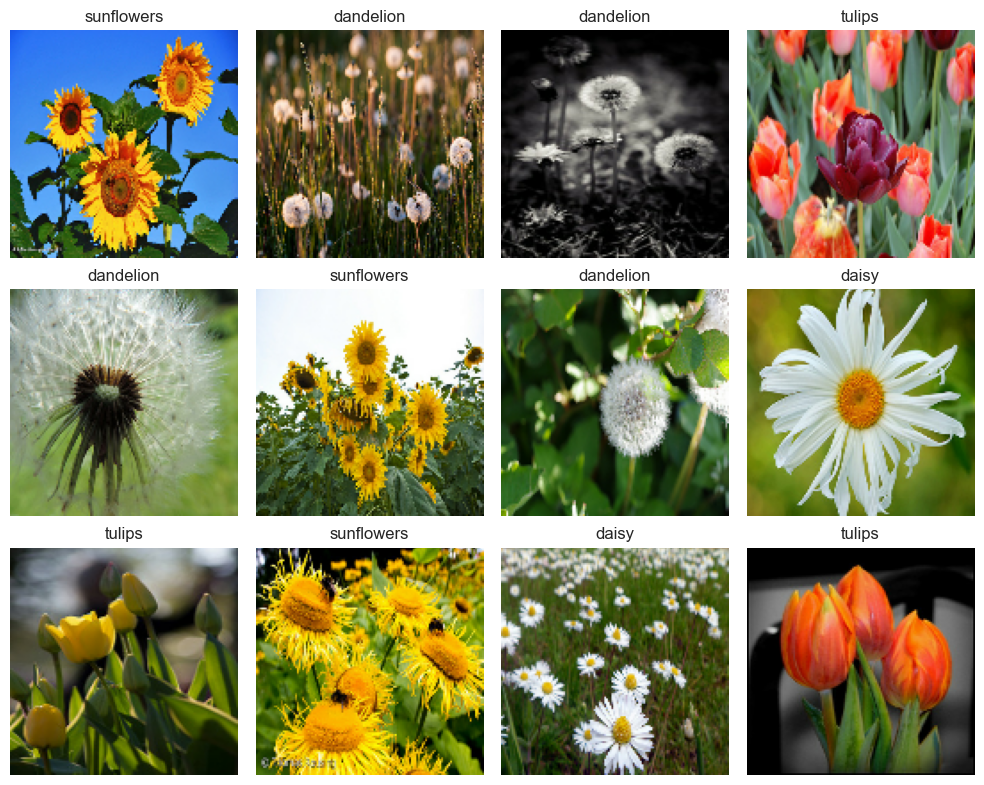

In [4]:
plt.figure(figsize=(10, 8))
for images, labels in train_ds.take(1):
    for index in range(12):
        plt.subplot(3, 4, index + 1)
        plt.imshow(images[index].numpy().astype("uint8"))
        plt.title(class_names[labels[index]])
        plt.axis("off")
plt.tight_layout(); plt.show()

## 5. What Is Transfer Learning?

Transfer learning reuses visual features learned by a model on a large dataset such as ImageNet. We keep the pretrained base and replace its original classifier with a small head for our flower classes. This usually needs less data and training time than learning every filter from scratch.

## 6. Data Augmentation and Frozen MobileNetV2 Base

In [5]:
data_augmentation = Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.10),
    RandomZoom(0.10),
], name="augmentation")

base_model = MobileNetV2(
    input_shape=IMG_SIZE + (3,), include_top=False, weights="imagenet"
)
base_model.trainable = False

inputs = Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)
x = GlobalAveragePooling2D()(x)
x = Dropout(0.30)(x)
outputs = Dense(len(class_names), activation="softmax")(x)
transfer_model = Model(inputs, outputs, name="flowers_mobilenetv2")

transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
print("Base model frozen:", not base_model.trainable)
transfer_model.summary()

Base model frozen: True


Model: "flowers_mobilenetv2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,264,389 (8.64 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 7. Train the New Classification Head

In [6]:
initial_callbacks = [
    EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=1, min_lr=1e-6),
]
initial_history = transfer_model.fit(
    train_ds, validation_data=val_ds, epochs=2 if FAST_RUN else 6,
    callbacks=initial_callbacks, verbose=2
)
initial_test_loss, initial_test_accuracy = transfer_model.evaluate(test_ds, verbose=0)
print(f"Frozen-base test accuracy: {initial_test_accuracy:.4f}")

Epoch 1/2


81/81 - 16s - 201ms/step - accuracy: 0.6193 - loss: 1.0068 - val_accuracy: 0.7810 - val_loss: 0.6344 - learning_rate: 1.0000e-03


Epoch 2/2


81/81 - 11s - 140ms/step - accuracy: 0.7894 - loss: 0.5771 - val_accuracy: 0.8061 - val_loss: 0.5331 - learning_rate: 1.0000e-03


Frozen-base test accuracy: 0.8382


## 8. Fine-Tune Final MobileNetV2 Layers

The last 20 base layers are made trainable, except batch-normalization layers. A very small learning rate protects the useful pretrained features from large updates.

In [7]:
base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False
for layer in base_model.layers[-20:]:
    if isinstance(layer, BatchNormalization):
        layer.trainable = False

transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
fine_history = transfer_model.fit(
    train_ds, validation_data=val_ds, epochs=1 if FAST_RUN else 4,
    callbacks=[EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)],
    verbose=2,
)
fine_test_loss, fine_test_accuracy = transfer_model.evaluate(test_ds, verbose=0)
print(f"Frozen-base test accuracy: {initial_test_accuracy:.4f}")
print(f"Fine-tuned test accuracy: {fine_test_accuracy:.4f}")

81/81 - 11s - 136ms/step - accuracy: 0.8416 - loss: 0.4429 - val_accuracy: 0.8241 - val_loss: 0.4890


Frozen-base test accuracy: 0.8382
Fine-tuned test accuracy: 0.8493


## 9. Training History and Comparison

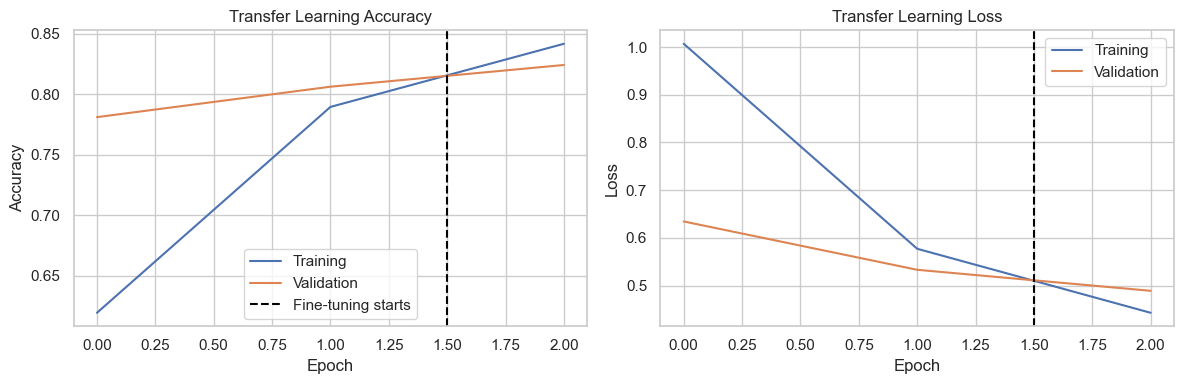

In [8]:
accuracy = initial_history.history["accuracy"] + fine_history.history["accuracy"]
val_accuracy = initial_history.history["val_accuracy"] + fine_history.history["val_accuracy"]
loss = initial_history.history["loss"] + fine_history.history["loss"]
val_loss = initial_history.history["val_loss"] + fine_history.history["val_loss"]
fine_start = len(initial_history.history["loss"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(accuracy, label="Training")
axes[0].plot(val_accuracy, label="Validation")
axes[0].axvline(fine_start - 0.5, color="black", linestyle="--", label="Fine-tuning starts")
axes[0].set(title="Transfer Learning Accuracy", xlabel="Epoch", ylabel="Accuracy")
axes[0].legend()
axes[1].plot(loss, label="Training")
axes[1].plot(val_loss, label="Validation")
axes[1].axvline(fine_start - 0.5, color="black", linestyle="--")
axes[1].set(title="Transfer Learning Loss", xlabel="Epoch", ylabel="Loss")
axes[1].legend()
plt.tight_layout(); plt.show()

## 10. Final Test Evaluation

In [9]:
y_true = np.concatenate([labels.numpy() for _, labels in test_ds])
probabilities = transfer_model.predict(test_ds, verbose=0)
y_pred = probabilities.argmax(axis=1)
print(f"Final test loss: {fine_test_loss:.4f}")
print(f"Final test accuracy: {fine_test_accuracy:.4f}")
print(classification_report(y_true, y_pred, target_names=class_names))

Final test loss: 0.4727
Final test accuracy: 0.8493
              precision    recall  f1-score   support

       daisy       0.94      0.86      0.90       101
   dandelion       0.94      0.85      0.89       131
       roses       0.74      0.88      0.81        99
  sunflowers       0.81      0.89      0.85       100
      tulips       0.83      0.78      0.80       113

    accuracy                           0.85       544
   macro avg       0.85      0.85      0.85       544
weighted avg       0.86      0.85      0.85       544



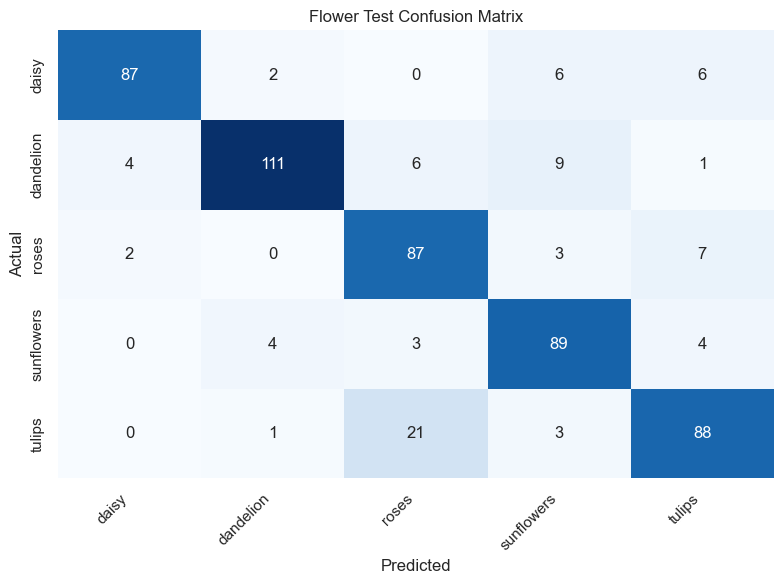

In [10]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=class_names, yticklabels=class_names)
plt.title("Flower Test Confusion Matrix")
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.xticks(rotation=45, ha="right")
plt.tight_layout(); plt.show()

## 11. Sample Predictions

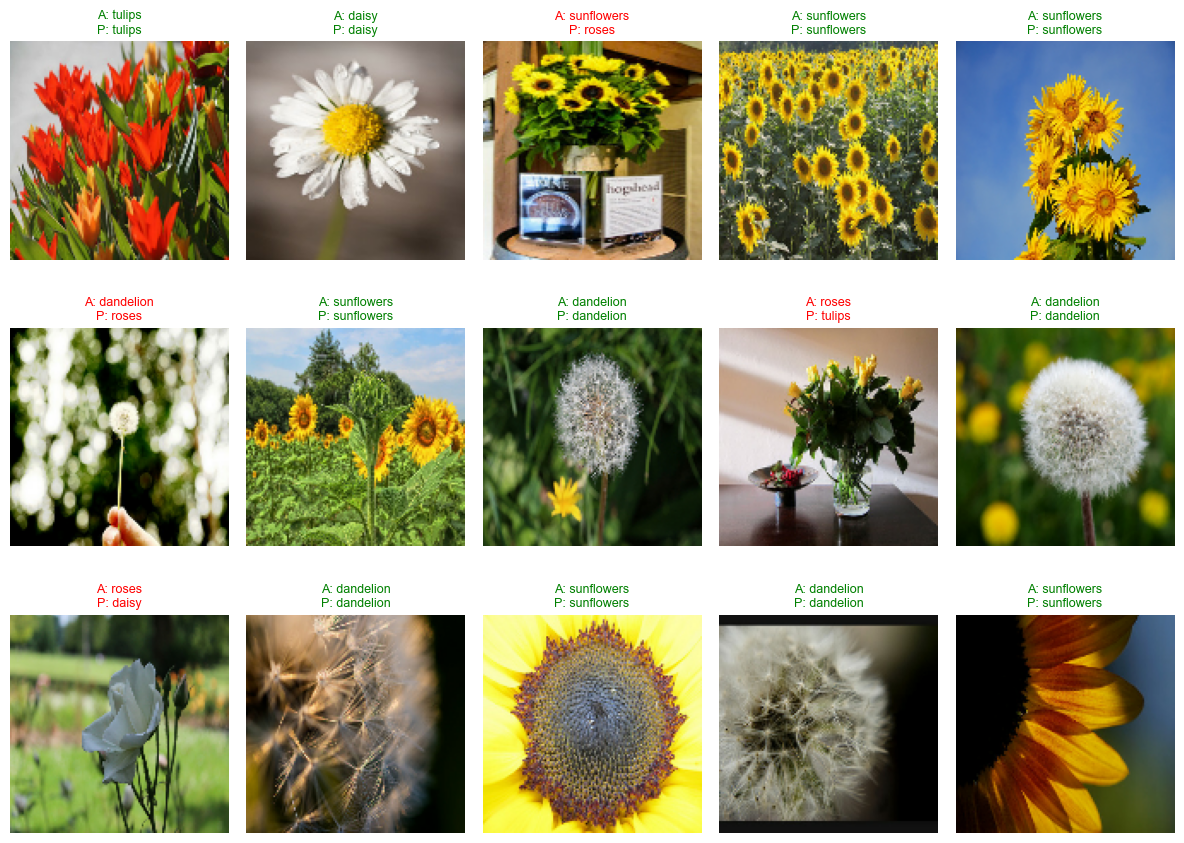

In [11]:
sample_images, sample_labels = next(iter(test_ds))
sample_probabilities = transfer_model.predict(sample_images, verbose=0)
sample_predictions = sample_probabilities.argmax(axis=1)
plt.figure(figsize=(12, 9))
for index in range(min(15, len(sample_images))):
    plt.subplot(3, 5, index + 1)
    plt.imshow(sample_images[index].numpy().astype("uint8"))
    color = "green" if sample_predictions[index] == sample_labels[index] else "red"
    plt.title(f"A: {class_names[sample_labels[index]]}\nP: {class_names[sample_predictions[index]]}", color=color, fontsize=9)
    plt.axis("off")
plt.tight_layout(); plt.show()

## 12. Conclusion

MobileNetV2 provides strong ImageNet features while the new head adapts them to five flower classes. The frozen-base and fine-tuned test accuracies are printed together above, and the final confusion matrix and examples show the real behavior on the held-out test subset.